# Análisis Estadístico - Oposiciones GSI AGE (2018-2025)
### Basado en las Memorias Oficiales de la CPS (INAP) y Datos Confirmados de la Convocatoria en Curso 2025

En este cuaderno interactivo se realiza el análisis estadístico y probabilístico completo de las oposiciones del **Cuerpo de Gestión de Sistemas e Informática (GSI)** de la Administración del Estado:
1. **Datos Confirmados 2025:** Solicitudes/Convocados, Presentados al 1er ejercicio y Aprobados del test en la convocatoria en curso.
2. **Modelo Predictivo 2025:** ¿Qué probabilidades o porcentaje de opositores se estima que aprueben el proceso y cuántas plazas quedarán desiertas?
3. **Ingreso Libre Histórico (2018-2024):** De cuánta gente echó la solicitud y cuánta se presentó, cuántos lograron plaza.
4. **Plazas Convocadas vs Desiertas:** Balance de cuántas plazas quedan desiertas de todas las ofertadas cada año.
5. **Criba por Ejercicios:** Comparativa histórica entre el 1er ejercicio (test) y el 2º ejercicio (caso práctico).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.autolayout'] = True


## 1. Carga de Datos Oficiales y Preparación
Cargamos los datasets oficiales del repositorio:
- `gsi_datos_completos.csv`: Histórico consolidado auditado 2018-2024.
- `gsi_convocatoria_2025_en_curso.csv`: Datos confirmados a fecha actual de la convocatoria 2025.


In [2]:
df_completo = pd.read_csv('gsi_datos_completos.csv')
df_2025_raw = pd.read_csv('gsi_convocatoria_2025_en_curso.csv')

df_libre = df_completo[df_completo['tipo_acceso'] == 'Ingreso Libre'].sort_values('convocatoria').copy().reset_index(drop=True)
df_promo = df_completo[df_completo['tipo_acceso'] == 'Promoción Interna'].sort_values('convocatoria').copy().reset_index(drop=True)

for d in [df_libre, df_promo]:
    d['plazas_desiertas'] = d['plazas_totales'] - d['superan_proceso_total']
    d['pct_aprobados_de_presentados'] = (d['superan_proceso_total'] / d['presentados_1ej_total'] * 100).round(2)
    d['pct_plazas_desiertas'] = (d['plazas_desiertas'] / d['plazas_totales'] * 100).round(2)
    d['pct_presentados_de_solicitudes'] = (d['presentados_1ej_total'] / d['solicitudes_total'] * 100).round(2)

convocatorias = df_libre['convocatoria'].astype(str).tolist()
x = np.arange(len(convocatorias))


## 2. Ingreso Libre: Solicitudes, Presentados y Aprobados (2018 - 2025)

> **Pregunta clave:** De las personas que echaron la solicitud y de las que fueron al examen, ¿cuántas lograron aprobar? ¿Y cuántas plazas quedaron sin cubrir?

Esta tabla incluye las convocatorias finalizadas (2018, 2019, 2022, 2024) y la **convocatoria 2025 en curso** con los datos confirmados del primer ejercicio y la proyección final:


In [3]:
tabla_general_libre = pd.DataFrame([
    {
        'Convocatoria': '2018',
        'Plazas': 218, 'Solicitudes': 2087, 'Presentados': 1027,
        'Aprobados (Plaza)': 144, '% Aprobados / Presentados': '14.02%',
        'Plazas Desiertas': 74, '% Plazas Desiertas': '33.94%',
        'Estado': 'Finalizada'
    },
    {
        'Convocatoria': '2019',
        'Plazas': 280, 'Solicitudes': 1574, 'Presentados': 719,
        'Aprobados (Plaza)': 143, '% Aprobados / Presentados': '19.89%',
        'Plazas Desiertas': 137, '% Plazas Desiertas': '48.93%',
        'Estado': 'Finalizada'
    },
    {
        'Convocatoria': '2022',
        'Plazas': 840, 'Solicitudes': 2437, 'Presentados': 1219,
        'Aprobados (Plaza)': 316, '% Aprobados / Presentados': '25.92%',
        'Plazas Desiertas': 524, '% Plazas Desiertas': '62.38%',
        'Estado': 'Finalizada'
    },
    {
        'Convocatoria': '2024',
        'Plazas': 995, 'Solicitudes': 2482, 'Presentados': 1033,
        'Aprobados (Plaza)': 410, '% Aprobados / Presentados': '39.69%',
        'Plazas Desiertas': 585, '% Plazas Desiertas': '58.79%',
        'Estado': 'Finalizada'
    },
    {
        'Convocatoria': '2025 (En curso)',
        'Plazas': 680, 'Solicitudes': 2774, 'Presentados': 1124,
        'Aprobados (Plaza)': '814 (1º Ej) / ~451 est.', '% Aprobados / Presentados': '72.42% (1º Ej) / ~40.1% est.',
        'Plazas Desiertas': '~229 est.', '% Plazas Desiertas': '~33.7% est.',
        'Estado': '1er Ej. Aprobado (2º Ej. Pendiente)'
    }
])
tabla_general_libre


,Convocatoria,Plazas,Solicitudes,Presentados,Aprobados (Plaza),% Aprobados / Presentados,Plazas Desiertas,% Plazas Desiertas,Estado
0,2018,218,2087,1027,144,14.02%,74,33.94%,Finalizada
1,2019,280,1574,719,143,19.89%,137,48.93%,Finalizada
2,2022,840,2437,1219,316,25.92%,524,62.38%,Finalizada
3,2024,995,2482,1033,410,39.69%,585,58.79%,Finalizada
4,2025 (En curso),680,2774,1124,814 (1º Ej) / ~451 est.,72.42% (1º Ej) / ~40.1% est.,~229 est.,~33.7% est.,1er Ej. Aprobado (2º Ej. Pendiente)


## 3. Convocatoria 2025 en Curso: Datos Oficiales y Modelo Predictivo

### 3.1 Datos Oficiales Confirmados del 1er Ejercicio
Celebrado el primer examen y publicadas las listas de aprobados, estos son los datos certificados:
- **Plazas convocadas (BOE 22/12/2025):** 680 plazas de Ingreso Libre (634 General + 46 Discapacidad) y 520 de Promoción Interna.
- **Convocados / Admitidos:** 2.774 en Ingreso Libre (2.639 General + 135 Discapacidad).
- **Presentados Reales:** 1.124 en Ingreso Libre (1.090 General + 34 Discapacidad, incluyendo incidencias).
- **Aprobados del 1er Ejercicio:** 814 personas (789 General + 25 Discapacidad). Tasa de aprobados sobre presentados: **72.42%**.


In [4]:
tabla_2025_detalle = pd.DataFrame([
    {
        'Modalidad / Cupo': 'Ingreso Libre - Cupo General',
        'Plazas': 634, 'Convocados': 2639, 'Presentados 1º Ej': 1084, 'Incidencias': 6,
        'Presentados Reales': 1090, '% Asistencia': '41.30%',
        'Aprobados 1º Ej': 789, '% Aprobados / Presentados': '72.39%',
        'Opositores / Plaza 2º Ej': '1.24'
    },
    {
        'Modalidad / Cupo': 'Ingreso Libre - Discapacidad (CRD)',
        'Plazas': 46, 'Convocados': 135, 'Presentados 1º Ej': 32, 'Incidencias': 2,
        'Presentados Reales': 34, '% Asistencia': '25.19%',
        'Aprobados 1º Ej': 25, '% Aprobados / Presentados': '73.53%',
        'Opositores / Plaza 2º Ej': '0.54'
    },
    {
        'Modalidad / Cupo': 'TOTAL INGRESO LIBRE 2025',
        'Plazas': 680, 'Convocados': 2774, 'Presentados 1º Ej': 1116, 'Incidencias': 8,
        'Presentados Reales': 1124, '% Asistencia': '40.52%',
        'Aprobados 1º Ej': 814, '% Aprobados / Presentados': '72.42%',
        'Opositores / Plaza 2º Ej': '1.20'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Cupo General',
        'Plazas': 494, 'Convocados': 182, 'Presentados 1º Ej': 38, 'Incidencias': 1,
        'Presentados Reales': 39, '% Asistencia': '21.43%',
        'Aprobados 1º Ej': 'Pendiente', '% Aprobados / Presentados': '—',
        'Opositores / Plaza 2º Ej': '0.08'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Discapacidad',
        'Plazas': 26, 'Convocados': 12, 'Presentados 1º Ej': 2, 'Incidencias': 0,
        'Presentados Reales': 2, '% Asistencia': '16.67%',
        'Aprobados 1º Ej': 'Pendiente', '% Aprobados / Presentados': '—',
        'Opositores / Plaza 2º Ej': '0.08'
    },
    {
        'Modalidad / Cupo': 'TOTAL PROMOCIÓN INTERNA 2025',
        'Plazas': 520, 'Convocados': 194, 'Presentados 1º Ej': 40, 'Incidencias': 1,
        'Presentados Reales': 41, '% Asistencia': '21.13%',
        'Aprobados 1º Ej': 'Pendiente', '% Aprobados / Presentados': '—',
        'Opositores / Plaza 2º Ej': '0.08'
    }
])
tabla_2025_detalle


,Modalidad / Cupo,Plazas,Convocados,Presentados 1º Ej,Incidencias,Presentados Reales,% Asistencia,Aprobados 1º Ej,% Aprobados / Presentados,Opositores / Plaza 2º Ej
0,Ingreso Libre - Cupo General,634,2639,1084,6,1090,41.30%,789,72.39%,1.24
1,Ingreso Libre - Discapacidad (CRD),46,135,32,2,34,25.19%,25,73.53%,0.54
2,TOTAL INGRESO LIBRE 2025,680,2774,1116,8,1124,40.52%,814,72.42%,1.20
3,Promoción Interna - Cupo General,494,182,38,1,39,21.43%,Pendiente,—,0.08
4,Promoción Interna - Discapacidad,26,12,2,0,2,16.67%,Pendiente,—,0.08
5,TOTAL PROMOCIÓN INTERNA 2025,520,194,40,1,41,21.13%,Pendiente,—,0.08


### 3.2 ¿Qué probabilidades o porcentaje de opositores se estima que aprueben el proceso?

1. **Competencia Real en el 2º Ejercicio:**
   - **General:** Hay 634 plazas para 789 aprobados (+ ~30 aspirantes con nota guardada $pprox$ 819 aspirantes). Hay **1.24 a 1.29 opositores por plaza** (0.80 plazas por aspirante). No existe una barrera de corte por competencia: basta alcanzar el 5/10 (corte legal).
   - **Discapacidad:** Hay 46 plazas y solo 25 aprobados. Ratio de **0.54 opositores por plaza** (sobran 21 plazas). Quien apruebe el 2º ejercicio tiene el **100% de probabilidad de plaza asegurada**.
2. **Proyección por Escenarios Estadísticos (Ingreso Libre):**


In [5]:
reserva_nota_est = 30
cand_gen_2ej = 789 + reserva_nota_est
cand_disc_2ej = 25

escenarios_2025 = [
    {
        'Escenario': '1. Conservador (Corte Exigente ~42% en 2º Ej, estilo 2018)',
        'Tasa Paso 2º Ej (Gen / Disc)': '42% / 60%',
        'Aprobados Estimados Gen': int(round(cand_gen_2ej * 0.42)),
        'Aprobados Estimados Disc': int(round(cand_disc_2ej * 0.60)),
        'Aprobados Totales Estimados': int(round(cand_gen_2ej * 0.42)) + int(round(cand_disc_2ej * 0.60)),
    },
    {
        'Escenario': '2. Moderado (Criterio Estándar ~53% en 2º Ej, estilo 2019/2022)',
        'Tasa Paso 2º Ej (Gen / Disc)': '53% / 68%',
        'Aprobados Estimados Gen': int(round(cand_gen_2ej * 0.53)),
        'Aprobados Estimados Disc': int(round(cand_disc_2ej * 0.68)),
        'Aprobados Totales Estimados': int(round(cand_gen_2ej * 0.53)) + int(round(cand_disc_2ej * 0.68)),
    },
    {
        'Escenario': '3. Optimista (Máxima Cobertura ~68% en 2º Ej, para cubrir plazas)',
        'Tasa Paso 2º Ej (Gen / Disc)': '68% / 76%',
        'Aprobados Estimados Gen': int(round(cand_gen_2ej * 0.68)),
        'Aprobados Estimados Disc': int(round(cand_disc_2ej * 0.76)),
        'Aprobados Totales Estimados': int(round(cand_gen_2ej * 0.68)) + int(round(cand_disc_2ej * 0.76)),
    }
]

df_escenarios_2025 = pd.DataFrame(escenarios_2025)
df_escenarios_2025['% Éxito s/ Presentados (1.124)'] = (df_escenarios_2025['Aprobados Totales Estimados'] / 1124 * 100).round(2).map('{:.2f}%'.format)
df_escenarios_2025['% Éxito s/ Aprobados 1º Ej (814)'] = (df_escenarios_2025['Aprobados Totales Estimados'] / 814 * 100).round(2).map('{:.2f}%'.format)
df_escenarios_2025['Plazas Desiertas Estimadas'] = 680 - df_escenarios_2025['Aprobados Totales Estimados']
df_escenarios_2025['% Plazas Desiertas Estimadas'] = (df_escenarios_2025['Plazas Desiertas Estimadas'] / 680 * 100).round(2).map('{:.2f}%'.format)
df_escenarios_2025


,Escenario,Tasa Paso 2º Ej (Gen / Disc),Aprobados Estimados Gen,Aprobados Estimados Disc,Aprobados Totales Estimados,% Éxito s/ Presentados (1.124),% Éxito s/ Aprobados 1º Ej (814),Plazas Desiertas Estimadas,% Plazas Desiertas Estimadas
0,"1. Conservador (Corte Exigente ~42% en 2º Ej, ...",42% / 60%,344,15,359,31.94%,44.10%,321,47.21%
1,"2. Moderado (Criterio Estándar ~53% en 2º Ej, ...",53% / 68%,434,17,451,40.12%,55.41%,229,33.68%
2,"3. Optimista (Máxima Cobertura ~68% en 2º Ej, ...",68% / 76%,557,19,576,51.25%,70.76%,104,15.29%


### 3.3 Gráfico: Embudo Convocatoria 2025 y Escenarios de Cobertura


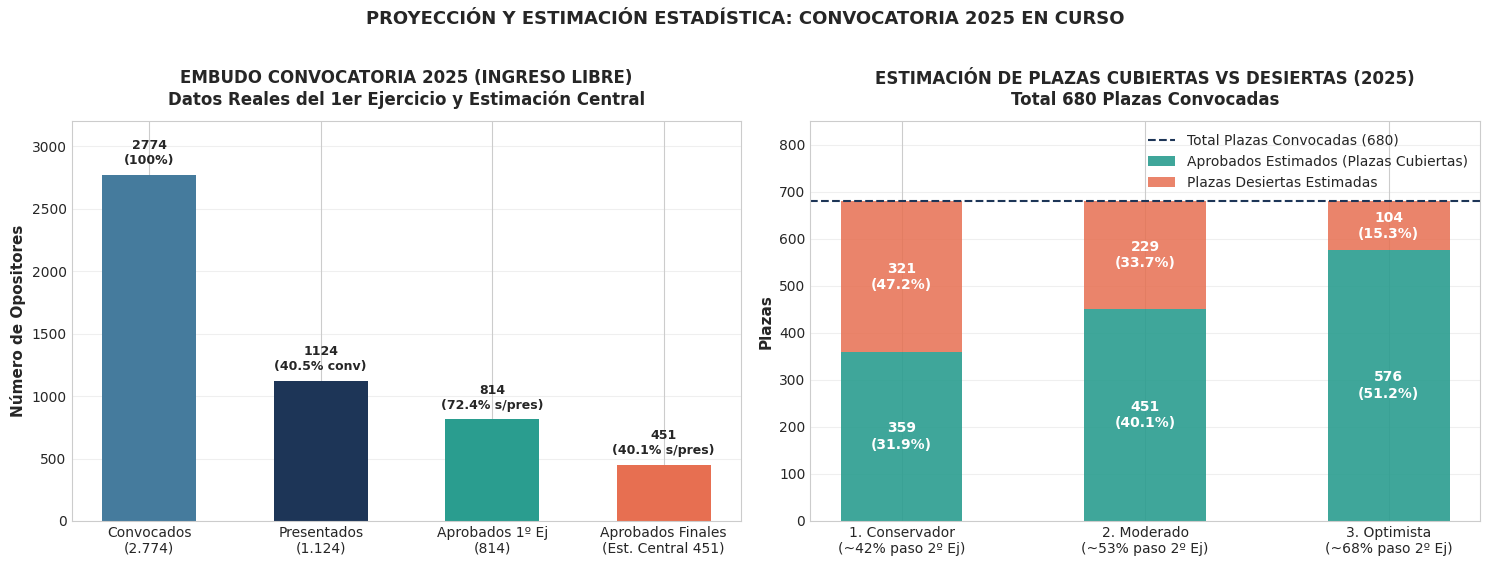

In [6]:
fig, (ax_f, ax_e) = plt.subplots(1, 2, figsize=(15, 5.5))

# Embudo 2025
etapas_2025 = ['Convocados\n(2.774)', 'Presentados\n(1.124)', 'Aprobados 1º Ej\n(814)', 'Aprobados Finales\n(Est. Central 451)']
valores_f = [2774, 1124, 814, 451]
colores_f = ['#457B9D', '#1D3557', '#2A9D8F', '#E76F51']
bars_f = ax_f.bar(etapas_2025, valores_f, color=colores_f, width=0.55)
ax_f.set_title('EMBUDO CONVOCATORIA 2025 (INGRESO LIBRE)\nDatos Reales del 1er Ejercicio y Estimación Central', fontsize=12, fontweight='bold', pad=12)
ax_f.set_ylabel('Número de Opositores', fontsize=11, fontweight='bold')
ax_f.set_ylim(0, 3200)
ax_f.grid(True, alpha=0.3, axis='y')

for bar, v in zip(bars_f, valores_f):
    pct_pres = v / 1124 * 100
    if v == 2774:
        txt = f'{v}\n(100%)'
    elif v == 1124:
        txt = f'{v}\n(40.5% conv)'
    else:
        txt = f'{v}\n({pct_pres:.1f}% s/pres)'
    ax_f.text(bar.get_x() + bar.get_width()/2., v + 60, txt, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Escenarios de Aprobados vs Plazas Desiertas en 2025
esc_nombres = ['1. Conservador\n(~42% paso 2º Ej)', '2. Moderado\n(~53% paso 2º Ej)', '3. Optimista\n(~68% paso 2º Ej)']
apr_esc = df_escenarios_2025['Aprobados Totales Estimados']
des_esc = df_escenarios_2025['Plazas Desiertas Estimadas']

ax_e.bar(esc_nombres, apr_esc, width=0.5, label='Aprobados Estimados (Plazas Cubiertas)', color='#2A9D8F', alpha=0.9)
ax_e.bar(esc_nombres, des_esc, width=0.5, bottom=apr_esc, label='Plazas Desiertas Estimadas', color='#E76F51', alpha=0.85)

ax_e.axhline(680, color='#1D3557', linestyle='--', linewidth=1.5, label='Total Plazas Convocadas (680)')
ax_e.set_title('ESTIMACIÓN DE PLAZAS CUBIERTAS VS DESIERTAS (2025)\nTotal 680 Plazas Convocadas', fontsize=12, fontweight='bold', pad=12)
ax_e.set_ylabel('Plazas', fontsize=11, fontweight='bold')
ax_e.set_ylim(0, 850)
ax_e.legend(fontsize=10, loc='upper right')
ax_e.grid(True, alpha=0.3, axis='y')

for i in range(len(esc_nombres)):
    ap = apr_esc.iloc[i]
    ds = des_esc.iloc[i]
    pct_apr_pres = ap / 1124 * 100
    ax_e.text(i, ap/2, f'{ap}\n({pct_apr_pres:.1f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax_e.text(i, ap + ds/2, f'{ds}\n({ds/680*100:.1f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.suptitle('PROYECCIÓN Y ESTIMACIÓN ESTADÍSTICA: CONVOCATORIA 2025 EN CURSO', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Resumen Histórico: ¿Cuántas plazas se quedan desiertas de todas las convocadas ese año? (Total GSI: Libre + Promo)

Sumando todas las modalidades ofertadas por el Estado en cada convocatoria (2018-2024):


In [7]:
tot_plz_yr = df_libre['plazas_totales'] + df_promo['plazas_totales']
tot_sol_yr = df_libre['solicitudes_total'] + df_promo['solicitudes_total']
tot_pres_yr = df_libre['presentados_1ej_total'] + df_promo['presentados_1ej_total']
tot_apr_yr = df_libre['superan_proceso_total'] + df_promo['superan_proceso_total']
tot_des_yr = tot_plz_yr - tot_apr_yr

tabla_total_gsi = pd.DataFrame({
    'Convocatoria': convocatorias,
    'Plazas Convocadas': tot_plz_yr,
    'Solicitudes Totales': tot_sol_yr,
    'Presentados al Examen': tot_pres_yr,
    'Aprobados (Plazas Cubiertas)': tot_apr_yr,
    '% Aprobados / Presentados': (tot_apr_yr / tot_pres_yr * 100).round(2).map('{:.2f}%'.format),
    'Plazas Desiertas ese Año': tot_des_yr,
    '% Plazas Desiertas': (tot_des_yr / tot_plz_yr * 100).round(2).map('{:.2f}%'.format)
})

fila_tot_global = pd.DataFrame([{
    'Convocatoria': 'TOTAL HISTÓRICO',
    'Plazas Convocadas': tot_plz_yr.sum(),
    'Solicitudes Totales': tot_sol_yr.sum(),
    'Presentados al Examen': tot_pres_yr.sum(),
    'Aprobados (Plazas Cubiertas)': tot_apr_yr.sum(),
    '% Aprobados / Presentados': f'{tot_apr_yr.sum()/tot_pres_yr.sum()*100:.2f}%',
    'Plazas Desiertas ese Año': tot_des_yr.sum(),
    '% Plazas Desiertas': f'{tot_des_yr.sum()/tot_plz_yr.sum()*100:.2f}%'
}])

tabla_total_gsi_final = pd.concat([tabla_total_gsi, fila_tot_global], ignore_index=True)
tabla_total_gsi_final


,Convocatoria,Plazas Convocadas,Solicitudes Totales,Presentados al Examen,Aprobados (Plazas Cubiertas),% Aprobados / Presentados,Plazas Desiertas ese Año,% Plazas Desiertas
0,2018,358,2283,1203,175,14.55%,183,51.12%
1,2019,480,1883,942,254,26.96%,226,47.08%
2,2022,1440,2903,1488,459,30.85%,981,68.12%
3,2024,1795,2867,1219,572,46.92%,1223,68.13%
4,TOTAL HISTÓRICO,4073,9936,4852,1460,30.09%,2613,64.15%


## 5. Radiografía Oficial de la Convocatoria 2024 al Detalle por Cupos

Datos oficiales certificados en la Memoria CPS 2024 para Cupo General y Cupo Discapacidad (CRD):


In [8]:
tabla_2024 = pd.DataFrame([
    {
        'Modalidad / Cupo': 'Ingreso Libre - Cupo General',
        'Plazas Convocadas': 937, 'Solicitudes': 2389, 'Presentados 1º Ej': 1004,
        'Superan Proceso (Plaza)': 397, '% Superan / Presentados': '39.54%',
        'Plazas Desiertas': 540, '% Plazas Desiertas': '57.63%'
    },
    {
        'Modalidad / Cupo': 'Ingreso Libre - Discapacidad (CRD)',
        'Plazas Convocadas': 58, 'Solicitudes': 93, 'Presentados 1º Ej': 29,
        'Superan Proceso (Plaza)': 13, '% Superan / Presentados': '44.83%',
        'Plazas Desiertas': 45, '% Plazas Desiertas': '77.59%'
    },
    {
        'Modalidad / Cupo': 'TOTAL INGRESO LIBRE 2024',
        'Plazas Convocadas': 995, 'Solicitudes': 2482, 'Presentados 1º Ej': 1033,
        'Superan Proceso (Plaza)': 410, '% Superan / Presentados': '39.69%',
        'Plazas Desiertas': 585, '% Plazas Desiertas': '58.79%'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Cupo General',
        'Plazas Convocadas': 754, 'Solicitudes': 366, 'Presentados 1º Ej': 178,
        'Superan Proceso (Plaza)': 155, '% Superan / Presentados': '87.08%',
        'Plazas Desiertas': 599, '% Plazas Desiertas': '79.44%'
    },
    {
        'Modalidad / Cupo': 'Promoción Interna - Discapacidad (CRD)',
        'Plazas Convocadas': 46, 'Solicitudes': 19, 'Presentados 1º Ej': 8,
        'Superan Proceso (Plaza)': 7, '% Superan / Presentados': '87.50%',
        'Plazas Desiertas': 39, '% Plazas Desiertas': '84.78%'
    },
    {
        'Modalidad / Cupo': 'TOTAL PROMOCIÓN INTERNA 2024',
        'Plazas Convocadas': 800, 'Solicitudes': 385, 'Presentados 1º Ej': 186,
        'Superan Proceso (Plaza)': 162, '% Superan / Presentados': '87.10%',
        'Plazas Desiertas': 638, '% Plazas Desiertas': '79.75%'
    },
    {
        'Modalidad / Cupo': 'TOTAL CONJUNTO GSI 2024',
        'Plazas Convocadas': 1795, 'Solicitudes': 2867, 'Presentados 1º Ej': 1219,
        'Superan Proceso (Plaza)': 572, '% Superan / Presentados': '46.92%',
        'Plazas Desiertas': 1223, '% Plazas Desiertas': '68.13%'
    }
])
tabla_2024


,Modalidad / Cupo,Plazas Convocadas,Solicitudes,Presentados 1º Ej,Superan Proceso (Plaza),% Superan / Presentados,Plazas Desiertas,% Plazas Desiertas
0,Ingreso Libre - Cupo General,937,2389,1004,397,39.54%,540,57.63%
1,Ingreso Libre - Discapacidad (CRD),58,93,29,13,44.83%,45,77.59%
2,TOTAL INGRESO LIBRE 2024,995,2482,1033,410,39.69%,585,58.79%
3,Promoción Interna - Cupo General,754,366,178,155,87.08%,599,79.44%
4,Promoción Interna - Discapacidad (CRD),46,19,8,7,87.50%,39,84.78%
5,TOTAL PROMOCIÓN INTERNA 2024,800,385,186,162,87.10%,638,79.75%
6,TOTAL CONJUNTO GSI 2024,1795,2867,1219,572,46.92%,1223,68.13%


## 6. Progresión por Ejercicios: ¿Cuántos superan el 1er Ejercicio y cuántos el Proceso Completo?
Comparativa de la progresión y filtros aplicados en cada convocatoria:


In [9]:
tabla_criba = pd.DataFrame([
    {
        'Convocatoria': '2018',
        'Tipo Examen': 'Dos exámenes separados',
        'Presentados 1º Ej': 1027,
        'Superan 1º Ej (Test)': 500,
        '% Superan 1º Ej': '48.69%',
        'Presentados 2º Ej': 350,
        'Superan Proceso (Plaza)': 144,
        '% Superan Proceso / Presentados 1º': '14.02%'
    },
    {
        'Convocatoria': '2019',
        'Tipo Examen': 'Dos exámenes separados',
        'Presentados 1º Ej': 719,
        'Superan 1º Ej (Test)': 350,
        '% Superan 1º Ej': '48.68%',
        'Presentados 2º Ej': 261,
        'Superan Proceso (Plaza)': 143,
        '% Superan Proceso / Presentados 1º': '19.89%'
    },
    {
        'Convocatoria': '2022',
        'Tipo Examen': 'Examen Único (Test + Caso)',
        'Presentados 1º Ej': 1219,
        'Superan 1º Ej (Test)': 'Sesión conjunta',
        '% Superan 1º Ej': '—',
        'Presentados 2º Ej': 'Misma sesión',
        'Superan Proceso (Plaza)': 316,
        '% Superan Proceso / Presentados 1º': '25.92%'
    },
    {
        'Convocatoria': '2024',
        'Tipo Examen': 'Examen Único (Test + Caso)',
        'Presentados 1º Ej': 1033,
        'Superan 1º Ej (Test)': 'Sesión conjunta',
        '% Superan 1º Ej': '—',
        'Presentados 2º Ej': 'Misma sesión',
        'Superan Proceso (Plaza)': 410,
        '% Superan Proceso / Presentados 1º': '39.69%'
    },
    {
        'Convocatoria': '2025 (En curso)',
        'Tipo Examen': 'Dos exámenes separados',
        'Presentados 1º Ej': 1124,
        'Superan 1º Ej (Test)': 814,
        '% Superan 1º Ej': '72.42%',
        'Presentados 2º Ej': '~840 est.',
        'Superan Proceso (Plaza)': '~451 est.',
        '% Superan Proceso / Presentados 1º': '~40.1% est.'
    }
])
tabla_criba


,Convocatoria,Tipo Examen,Presentados 1º Ej,Superan 1º Ej (Test),% Superan 1º Ej,Presentados 2º Ej,Superan Proceso (Plaza),% Superan Proceso / Presentados 1º
0,2018,Dos exámenes separados,1027,500,48.69%,350,144,14.02%
1,2019,Dos exámenes separados,719,350,48.68%,261,143,19.89%
2,2022,Examen Único (Test + Caso),1219,Sesión conjunta,—,Misma sesión,316,25.92%
3,2024,Examen Único (Test + Caso),1033,Sesión conjunta,—,Misma sesión,410,39.69%
4,2025 (En curso),Dos exámenes separados,1124,814,72.42%,~840 est.,~451 est.,~40.1% est.


## 7. Gráficos Históricos Comparativos

### Gráfico: Solicitudes vs Presentados vs Aprobados (Ingreso Libre 2018-2024)


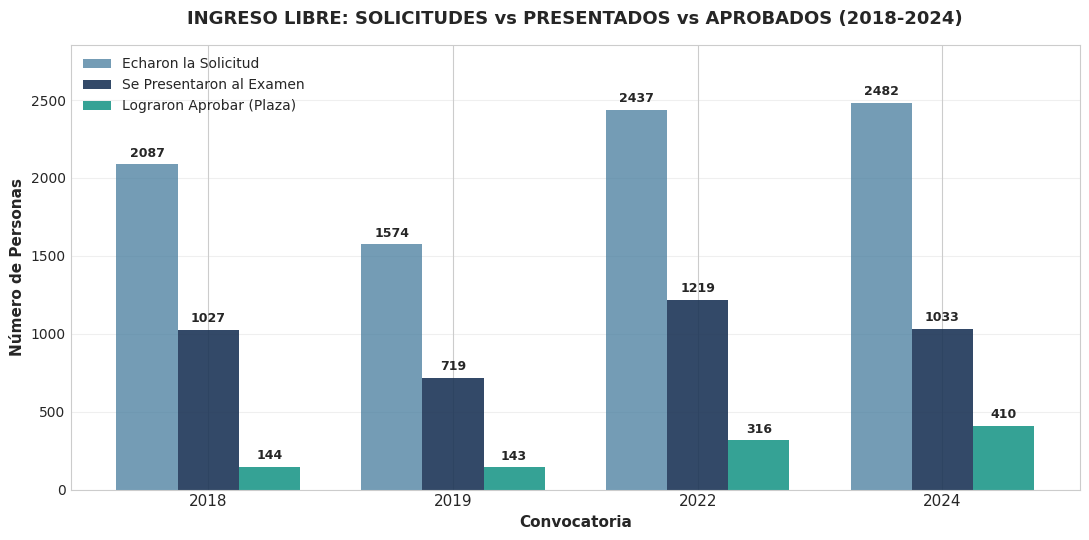

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
width_grp = 0.25

b_sol = ax.bar(x - width_grp, df_libre['solicitudes_total'], width_grp, label='Echaron la Solicitud', color='#457B9D', alpha=0.75)
b_pres = ax.bar(x, df_libre['presentados_1ej_total'], width_grp, label='Se Presentaron al Examen', color='#1D3557', alpha=0.9)
b_apr = ax.bar(x + width_grp, df_libre['superan_proceso_total'], width_grp, label='Lograron Aprobar (Plaza)', color='#2A9D8F', alpha=0.95)

ax.set_title('INGRESO LIBRE: SOLICITUDES vs PRESENTADOS vs APROBADOS (2018-2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Personas', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(convocatorias, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(df_libre['solicitudes_total']) * 1.15)

for bars in [b_sol, b_pres, b_apr]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 30, f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Gráfico: De los que se presentaron, ¿qué porcentaje logró aprobar?


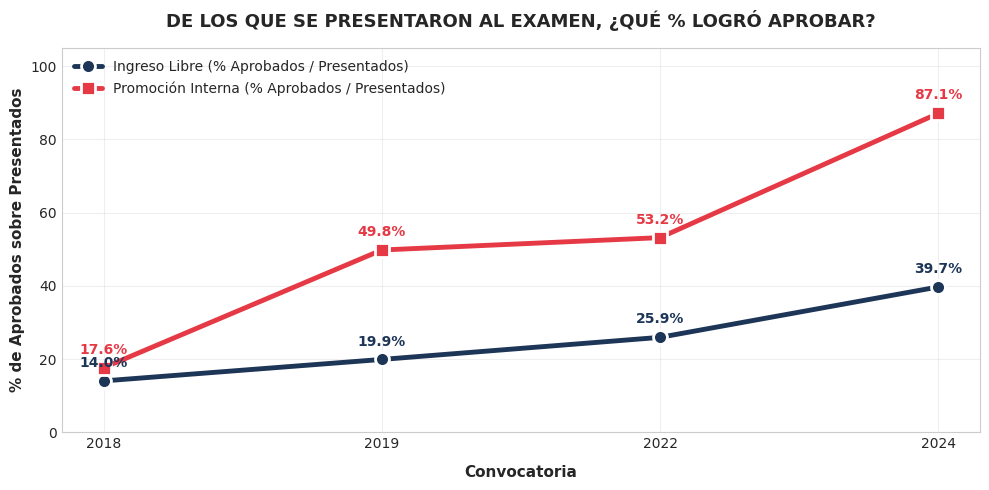

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(convocatorias, df_libre['pct_aprobados_de_presentados'], 'o-', linewidth=3.5, markersize=10, 
        label='Ingreso Libre (% Aprobados / Presentados)', color='#1D3557', markeredgecolor='white', markeredgewidth=2)
ax.plot(convocatorias, df_promo['pct_aprobados_de_presentados'], 's-', linewidth=3.5, markersize=10, 
        label='Promoción Interna (% Aprobados / Presentados)', color='#E63946', markeredgecolor='white', markeredgewidth=2)

ax.set_xlabel('Convocatoria', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('% de Aprobados sobre Presentados', fontsize=11, fontweight='bold')
ax.set_title('DE LOS QUE SE PRESENTARON AL EXAMEN, ¿QUÉ % LOGRÓ APROBAR?', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')

for i, (v_lib, v_pro) in enumerate(zip(df_libre['pct_aprobados_de_presentados'], df_promo['pct_aprobados_de_presentados'])):
    ax.annotate(f'{v_lib:.1f}%', (i, v_lib), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#1D3557')
    ax.annotate(f'{v_pro:.1f}%', (i, v_pro), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#E63946')

plt.tight_layout()
plt.show()


### Gráfico: Plazas Convocadas vs Desiertas (Ingreso Libre y Total GSI)


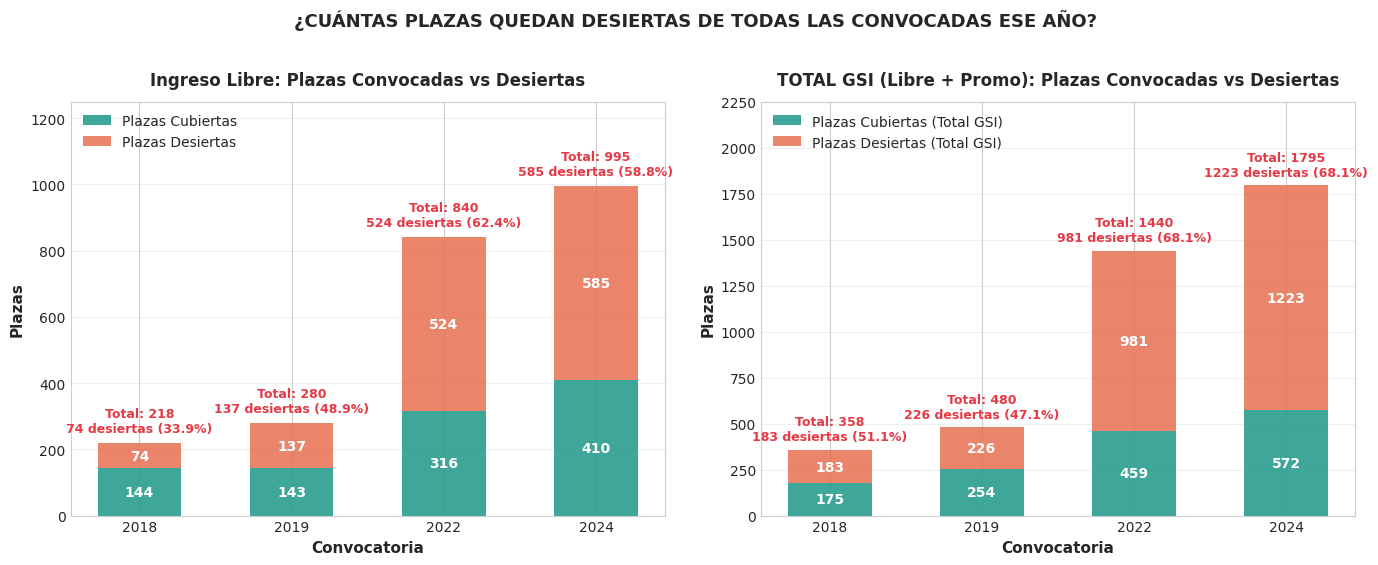

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Libre
ax1.bar(convocatorias, df_libre['superan_proceso_total'], width=0.55, label='Plazas Cubiertas', color='#2A9D8F', alpha=0.9)
ax1.bar(convocatorias, df_libre['plazas_desiertas'], width=0.55, bottom=df_libre['superan_proceso_total'], label='Plazas Desiertas', color='#E76F51', alpha=0.85)
ax1.set_title('Ingreso Libre: Plazas Convocadas vs Desiertas', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Plazas', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1250)

for i in range(len(convocatorias)):
    tot = df_libre['plazas_totales'].iloc[i]
    des = df_libre['plazas_desiertas'].iloc[i]
    cub = df_libre['superan_proceso_total'].iloc[i]
    pct_d = df_libre['pct_plazas_desiertas'].iloc[i]
    ax1.text(i, tot + 25, f'Total: {tot}\n{des} desiertas ({pct_d:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E63946')
    ax1.text(i, cub/2, f'{cub}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax1.text(i, cub + des/2, f'{des}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Total GSI (Libre + Promo)
ax2.bar(convocatorias, tot_apr_yr, width=0.55, label='Plazas Cubiertas (Total GSI)', color='#2A9D8F', alpha=0.9)
ax2.bar(convocatorias, tot_des_yr, width=0.55, bottom=tot_apr_yr, label='Plazas Desiertas (Total GSI)', color='#E76F51', alpha=0.85)
ax2.set_title('TOTAL GSI (Libre + Promo): Plazas Convocadas vs Desiertas', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax2.set_ylabel('Plazas', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 2250)

for i in range(len(convocatorias)):
    tot_g = tot_plz_yr.iloc[i]
    des_g = tot_des_yr.iloc[i]
    cub_g = tot_apr_yr.iloc[i]
    pct_dg = des_g / tot_g * 100
    ax2.text(i, tot_g + 35, f'Total: {tot_g}\n{des_g} desiertas ({pct_dg:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E63946')
    ax2.text(i, cub_g/2, f'{cub_g}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax2.text(i, cub_g + des_g/2, f'{des_g}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.suptitle('¿CUÁNTAS PLAZAS QUEDAN DESIERTAS DE TODAS LAS CONVOCADAS ESE AÑO?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Conclusiones y Resumen para el Opositor

1. **¿Qué probabilidades o qué porcentaje de opositores se estima que aprueben el proceso en 2025?:**
   - **Para quien acudió al primer examen (1.124 personas):** Se estima una probabilidad de entre el **31.9% y el 51.3%** de conseguir plaza (escenario central: **~40.1%**).
   - **Para quien ya está en la lista de aprobados del 1er ejercicio (814 personas):** Su probabilidad de lograr plaza definitiva se sitúa entre el **44.1% y el 70.8%** (escenario central: **~55.4%**). ¡Más de la mitad de los que han pasado el test serán funcionarios de carrera!
   - **En el Cupo de Discapacidad:** Al haber 46 plazas y solo 25 aprobados, **todo aspirante que supere la nota de corte del segundo examen tiene el 100% de probabilidad de plaza asegurada**.

2. **¿Cuántas plazas quedarán desiertas en 2025?:**
   - En **Ingreso Libre (680 plazas)**: se estima que quedarán desiertas entre **104 y 321 plazas** (proyección central: **~229 plazas vacías, el 33.7%**).
   - En **Promoción Interna (520 plazas)**: solo se presentaron 41 personas. Quedarán desiertas como mínimo **479 plazas (el 92.1%)**.

3. **Conclusión histórica global (2018-2024):**
   - En las últimas 4 convocatorias finalizadas, **el 64.15% de todas las plazas de GSI convocadas han quedado desiertas** (2.613 de 4.073 plazas).
   - El gran rival del opositor de GSI nunca es la competencia con otros aspirantes, sino **alcanzar la nota mínima legal del 50% fijada por el Tribunal**.
